# STAT 207 Homework 9 [25 points]

## Logistic Regression & Classifiers

Due: Monday, April 13, end of day (11:59 pm CT)

Late submissions accepted until Tuesday, April 14 at noon

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.formula.api as smf

## Case Study: Heart Disease

Can we identify patients who have heart disease based on other patient characteristics?

We will use the following information about patients:

- **`age`**: age
- **`sex`**: sex, 1 = male, 0 = female
- **`cp`**: chest pain type, 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
- **`trestbps`**: resting blood pressure (in mm Hg)
- **`chol`**: serum cholesterol in mg/dl
- **`fbs`**: whether the fasting blood sugar is above 120 mg/dl (1 = true, 0 = false)
- **`restecg`**: resting electrocardiographic results (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy)
- **`thalach`**: maximum heart rate achieved
- **`exang`**: exercise induced angina (1 = yes, 0 = no)
- **`oldpeak`**: ST depression induced by exercise relative to rest
- **`slope`**: the slope of the peak exercise ST segment (1 = upsloping, 2 = flat, 3 = downsloping)
- **`ca`**: number of major vessels (0-3) colored by flouroscopy (for calcification of vessels)
- **`thal`**: number of nuclear stress test (3 = normal, 6 = fixed defect, 7 = reversible defect)
- **`num`**: target number of progression of heart disease (1+ indicates at least 50% narrowing
- **`y`**: our target, generated below, for the presence of heart disease (1 = present, 0 = absent)

The data originally came from https://archive.ics.uci.edu/dataset/45/heart+disease.

Run the code in the cell below to read in the data for this document.  The data is saved as `df` with this code.  

In [24]:
df = pd.read_csv('processed_cleveland.csv', na_values = ['?'])
df = df.dropna()
df['y'] = 1 * (df['num'] > 0)
df['sex'] = df['sex'].replace({1: 'male', 0: 'female'})
df['cp'] = df['cp'].replace({1: 'typical', 2:'atypical', 3: 'non-anginal', 4: 'asymptomatic'})
df['fbs'] = df['fbs'].replace({1: 'high', 0: 'typical'})
df['restecg'] = df['restecg'].replace({0: 'normal', 1:'ST-T wave abnormality', 2: 'left ventricular hypertrophy'})
df['exang'] = df['exang'].replace({0: 'no', 1: 'yes'})
df['slope'] = df['slope'].replace({1:'upsloping', 2:'flat', 3:'downsloping'})
df['thal'] = df['thal'].replace({3: 'normal', 6: 'fixed defect', 7:'reversible defect'})

In [25]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,y
0,63,male,typical,145,233,high,left ventricular hypertrophy,150,no,2.3,downsloping,0.0,fixed defect,0,0
1,67,male,asymptomatic,160,286,typical,left ventricular hypertrophy,108,yes,1.5,flat,3.0,normal,2,1
2,67,male,asymptomatic,120,229,typical,left ventricular hypertrophy,129,yes,2.6,flat,2.0,reversible defect,1,1
3,37,male,non-anginal,130,250,typical,normal,187,no,3.5,downsloping,0.0,normal,0,0
4,41,female,atypical,130,204,typical,left ventricular hypertrophy,172,no,1.4,upsloping,0.0,normal,0,0


The code below will split the data into a training and a test data, using 20% as our test data and a random state of 406.  We will use our training data exclusively for the first three questions of the assignment.  We won't turn to the test data until the last question.

In [26]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size = 0.20, random_state = 406)

## 1. Using a Logistic Regression Model [1 point] + [6 points]

We know that we would like to predict the presence of heart disease (y).  First, we'll consider a simple model that uses age alone to predict the presence of heart disease.

**a)** Below, fit the model predicting the presence of heart disease from age using the training data.  Print the summary of the model.

In [27]:
log_model = smf.logit('y ~ age', data=df_train).fit()
print(log_model.summary())

Optimization terminated successfully.
         Current function value: 0.671099
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.02820
Time:                        15:01:55   Log-Likelihood:                -159.05
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                  0.002381
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6432      0.858     -3.082      0.002      -4.324      -0.962
age            0.0453      0.

**b)** I'd suggest turning to Q1 on Gradescope here.

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

In [28]:
patient = pd.DataFrame({'age': [35]})
log_model.predict(patient)

0    0.257926
dtype: float64

In [29]:
import numpy as np
age_threshold = ((np.log(.7/.3)) - (-2.6432)) / .0453
age_threshold

np.float64(77.05293290037977)

## 2. Evaluating Model Assumptions [1 point]

**a)** Generate the fitted vs. deviance residual plot for the model from Question 1 using the training data.

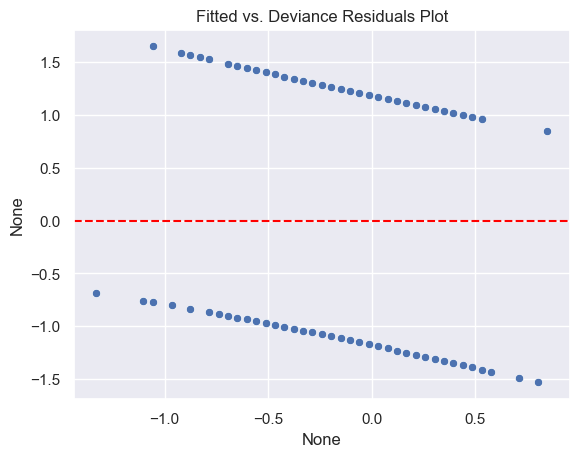

In [32]:
fitted = log_model.fittedvalues
dev_resid = log_model.resid_dev
sns.scatterplot(x=fitted, y=dev_resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Fitted vs. Deviance Residuals Plot')
plt.show()

**b)** I'd suggest turning to Q2 on Gradescope here.

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

## 3. Fitting a More Complex Model [1 point]

**a)** We'd like to explore how effective advanced tests are at recognizing the risk of heart disease.  We'll fit a second model to the training data predicting `y` from `age`, `sex`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, and `thal`.  Be sure to print the output of your model below.

In [34]:
log_model2 = smf.logit(
    'y ~ age + sex + restecg + thalach + exang + oldpeak + slope + ca + thal',
    data=df_train
).fit()
print(log_model2.summary())

Optimization terminated successfully.
         Current function value: 0.369234
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  237
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                           12
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.4653
Time:                        15:05:05   Log-Likelihood:                -87.509
converged:                       True   LL-Null:                       -163.67
Covariance Type:            nonrobust   LLR p-value:                 1.922e-26
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.3158

**b)** I'd suggest turning to Q3 on Gradescope here.

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

In [35]:
log_model2.prsquared


np.float64(0.46532134597983543)

In [36]:
from sklearn.metrics import roc_auc_score
y_true = df_train['y']
y_pred_prob = log_model2.predict(df_train)
auc = roc_auc_score(y_true, y_pred_prob)
print(auc)

0.9141732283464566


## 4. Build a Classifier [1.5 points]

**a)** Using the model from **Question 3**, build a classifier to our training data using a predictive probability threshold of 0.75.  Then, generate a confusion matrix from this model.

In [39]:
df_train['pred_prob'] = log_model2.predict(df_train)
df_train['y_pred'] = 1 * (df_train['pred_prob'] >= 0.75)
pd.crosstab(
    df_train['y'],
    df_train['y_pred'],
    rownames=['Actual'],
    colnames=['Predicted']
)

Predicted,0,1
Actual,,
0,120,7
1,38,72


0.810126582278481

**b)** I'd suggest turning to Q4 on Gradescope here.

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

In [41]:
accuracy = (120 + 72) / (120 + 7 + 38 + 72)
accuracy

0.810126582278481

## 5. Test Data [1 point]

**a)** Apply your logistic regression model from **Question 3** to your test data, calculating the predicted probabilities on your test data.

*Hint:* You do not need to fit a new model to answer this question.  

*Check Your Work*: You can check your sample size to ensure that you are only using the test data for this question.

In [ ]:
df_test['pred_prob'] = log_model2.predict(df_test)
df_test['pred_prob']


210    0.021102
301    0.135665
222    0.016833
186    0.230988
215    0.697363
207    0.938664
283    0.053396
209    0.185636
55     0.989218
107    0.833837
262    0.020218
206    0.994974
71     0.794896
180    0.595405
239    0.062724
133    0.223090
66     0.386641
32     0.050956
25     0.064848
269    0.080567
220    0.139929
41     0.631796
103    0.167409
147    0.044275
80     0.776244
295    0.041509
270    0.957892
34     0.162057
273    0.097674
24     0.993393
275    0.608639
58     0.381511
28     0.081996
265    0.713137
242    0.020857
63     0.016680
140    0.160820
231    0.611986
20     0.659697
248    0.764896
52     0.328144
288    0.408352
253    0.059831
256    0.186285
79     0.914915
146    0.988511
54     0.885909
153    0.961761
119    0.944011
89     0.068594
99     0.072957
158    0.918237
96     0.966773
175    0.978669
29     0.970941
97     0.896450
86     0.135394
62     0.997586
171    0.898104
82     0.089041
Name: pred_prob, dtype: float64

In [43]:
df_test.shape


(60, 16)

**b)** I'd suggest turning to Q5 on Gradescope here.

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

In [44]:
df_test['pred_prob'] = log_model2.predict(df_test)
df_test['y_pred'] = 1 * (df_test['pred_prob'] >= 0.75)
accuracy_test = (df_test['y_pred'] == df_test['y']).mean()
accuracy_test

np.float64(0.8333333333333334)

## 6. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

No

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use (including links, if appropriate)?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

n/a

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 9 Canvas Assignment to submit your notebook to GitHub.